# Credit scoring model

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("GiveMeSomeCredit-training.csv")
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
df.shape

(150000, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [5]:
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [6]:
df.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [7]:
df.fillna({
    "MonthlyIncome": df["MonthlyIncome"].median(),
    "NumberOfDependents": df["NumberOfDependents"].median()
}, inplace=True)

In [8]:
df.isnull().sum()

Unnamed: 0                              0
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

In [9]:
df.drop("Unnamed: 0", axis=1, inplace=True)

# Exploratory Data Analysis (EDA)

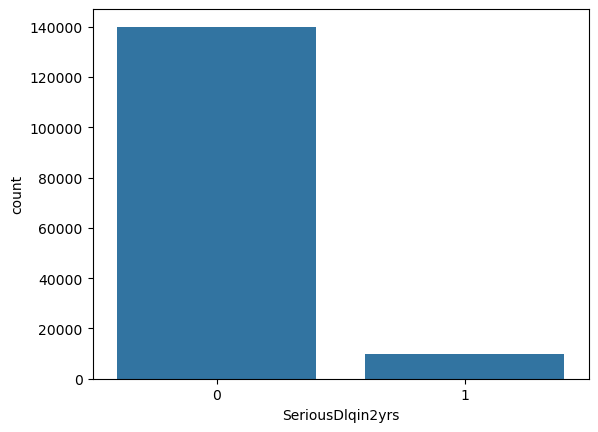

In [10]:
sns.countplot(
    x="SeriousDlqin2yrs",
    data=df
)

plt.show()

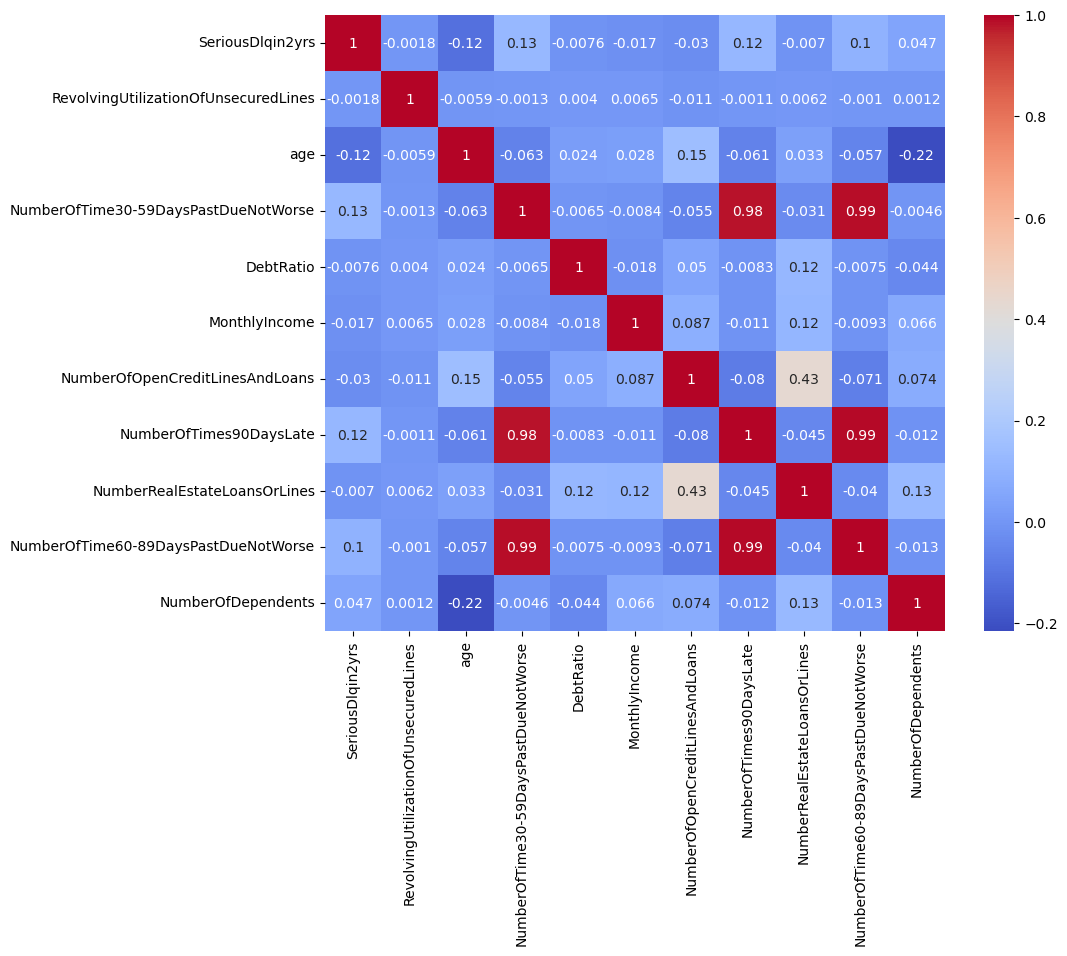

In [11]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

# Feature Engineering

In [12]:
df["IncomePerDependent"] = (
    df["MonthlyIncome"] /
    (df["NumberOfDependents"] + 1)
)

In [13]:
df["DebtIncomeRatio"] = (
    df["DebtRatio"] /
    (df["MonthlyIncome"] + 1)
)

# Split data

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop(
    "SeriousDlqin2yrs",
    axis = 1
)
y = df["SeriousDlqin2yrs"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,random_state=42,stratify=y
)


# Logistic Regression

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter = 1000)
model.fit(X_train, y_train)

C:\Users\susom\anaconda3\envs\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [20]:
pred3 = model.predict(X_test)

print(accuracy_score(y_test,pred3))
print(precision_score(y_test,pred3))
print(recall_score(y_test,pred3))
print(f1_score(y_test,pred3))

0.9334333333333333
0.5227272727272727
0.04588528678304239
0.08436497019715727


In [21]:
prob_lr = model.predict_proba(X_test)[:,1]
from sklearn.metrics import roc_auc_score
print(roc_auc_score(y_test, prob_lr))

0.7142832328002997


# Random Forest

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

# Evaluation

In [23]:
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
roc_auc_score
)

In [24]:
pred = rf.predict(X_test)

print(accuracy_score(y_test,pred))
print(precision_score(y_test,pred))
print(recall_score(y_test,pred))
print(f1_score(y_test,pred))

0.9362
0.5698924731182796
0.18503740648379052
0.27936746987951805


In [25]:
## ROC - AUC

prob = rf.predict_proba(X_test)[:,1]
roc_auc_score(y_test,prob)

0.8486417016932576

# Features importance

In [26]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
0,RevolvingUtilizationOfUnsecuredLines,0.155464
3,DebtRatio,0.123890
11,DebtIncomeRatio,0.116337
1,age,0.100990
10,IncomePerDependent,0.099178
4,MonthlyIncome,0.096065
6,NumberOfTimes90DaysLate,0.085620
5,NumberOfOpenCreditLinesAndLoans,0.072788
2,NumberOfTime30-59DaysPastDueNotWorse,0.048684
8,NumberOfTime60-89DaysPastDueNotWorse,0.048643


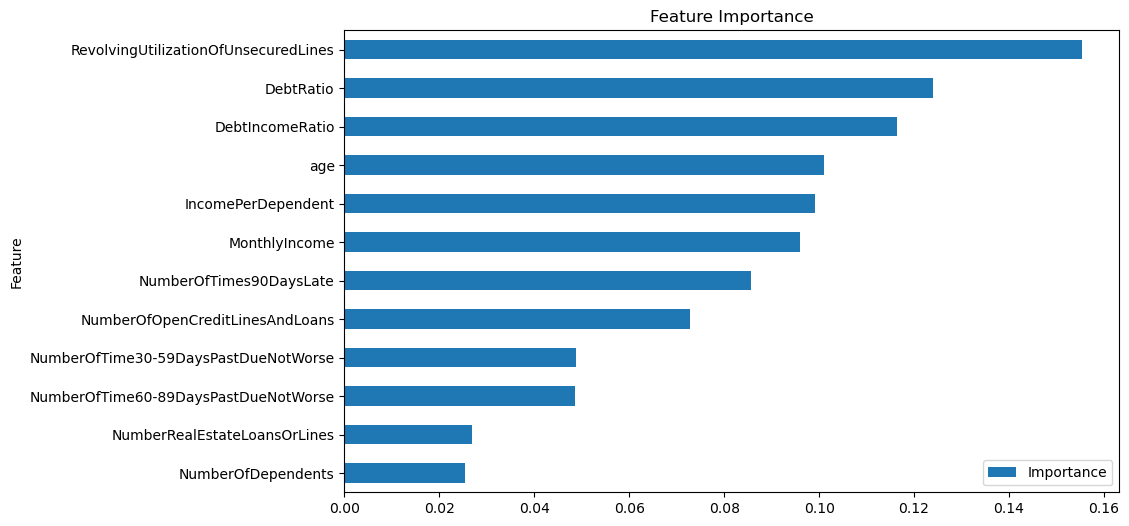

In [27]:
importance.sort_values(
    by='Importance',
    ascending=True
).plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(10,6)
)

plt.title("Feature Importance")
plt.show()

In [28]:
from sklearn.metrics import confusion_matrix

pred = rf.predict(X_test)

cm = confusion_matrix(y_test, pred)
print(cm)

[[27715   280]
 [ 1634   371]]


# Decision Tree

In [30]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(
    random_state = 42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

<Axes: xlabel='SeriousDlqin2yrs', ylabel='count'>

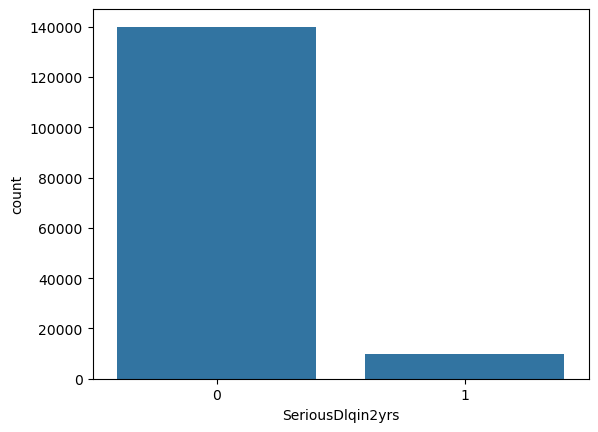

In [31]:
sns.countplot(x='SeriousDlqin2yrs', data=df)

<Axes: >

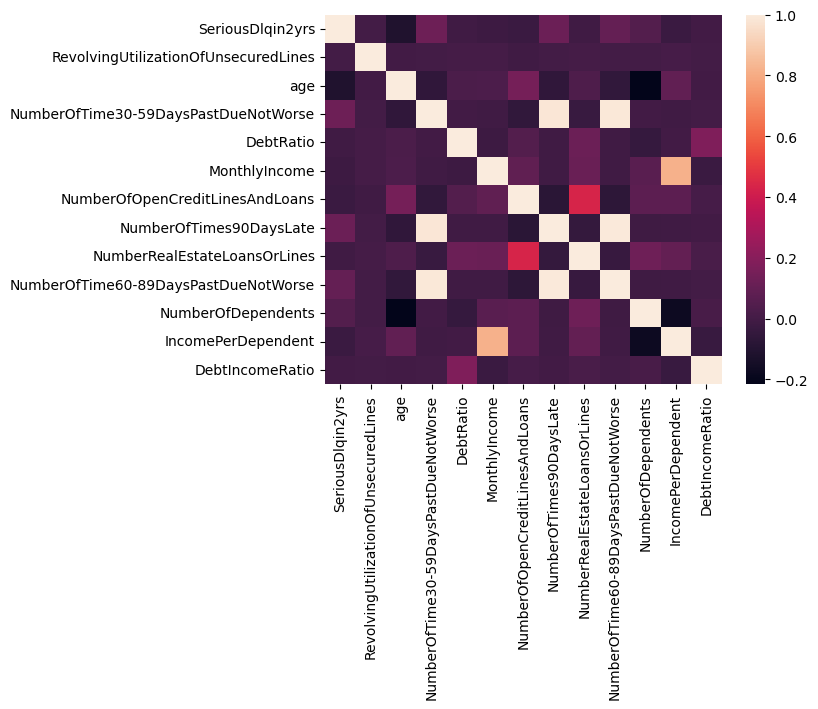

In [32]:
sns.heatmap(df.corr(), annot=False)

In [33]:
pred2 = dt.predict(X_test)

print(accuracy_score(y_test,pred2))
print(precision_score(y_test,pred2))
print(recall_score(y_test,pred2))
print(f1_score(y_test,pred2))

0.8992
0.2597831211692598
0.2748129675810474
0.26708676684440136


In [34]:
## ROC - AUC

prob2 = dt.predict_proba(X_test)[:,1]

roc_auc_score(
    y_test,
    prob2
)

0.6102581196588811

In [35]:
import joblib

joblib.dump(rf, "credit_scoring_model.pkl")

['credit_scoring_model.pkl']